# Data generation

# Libraries Generation

In [2]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import random
from typing import List, Dict, Optional, Tuple  
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go



# Setting random seed for reproducibility

In [3]:
np.random.seed(42)
random.seed(42)

# Setting of  plotting style

In [4]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [12]:
print("Libraries imported successfully!")

Libraries imported successfully!


# Defining the  Data Generator Class

In [13]:
class DataGenerator:
    """Generate synthetic water quality and AMR data"""
    
    def __init__(self, random_seed: int = 42):
        np.random.seed(random_seed)
        random.seed(random_seed)
        
    def generate_water_quality(
        self, 
        n_samples: int = 1000,
        start_date: str = "2020-01-01",
        end_date: str = "2023-12-31",
        locations: List[str] = None
    ) -> pd.DataFrame:
        """Generate synthetic water quality data"""
        
        print(f"Generating {n_samples} water quality samples...")
        
        # Generate dates
        dates = pd.date_range(start=start_date, end=end_date, periods=n_samples)
        
        # Default locations
        if locations is None:
            locations = [
                "River_A (Urban)", 
                "River_B (Agricultural)", 
                "Lake_C (Recreational)", 
                "Well_D (Groundwater)", 
                "Reservoir_E (Drinking Water)"
            ]
        
        # Generate water quality parameters
        data = {
            'sample_id': range(n_samples),
            'date': np.random.choice(dates, n_samples),
            'location': np.random.choice(locations, n_samples),
            'latitude': np.random.uniform(40.0, 42.0, n_samples),
            'longitude': np.random.uniform(-74.0, -72.0, n_samples),
            
            # Physical parameters
            'pH': np.random.normal(7.2, 0.5, n_samples),
            'temperature_c': np.random.normal(15, 5, n_samples),
            'turbidity_ntu': np.random.exponential(5, n_samples),
            'conductivity_us_cm': np.random.normal(300, 100, n_samples),
            
            # Chemical parameters
            'dissolved_oxygen_mgl': np.random.normal(8, 1.5, n_samples),
            'bod_mgl': np.random.exponential(3, n_samples),
            'cod_mgl': np.random.exponential(10, n_samples),
            'nitrate_mgl': np.random.gamma(2, 2, n_samples),
            'phosphate_mgl': np.random.gamma(1, 0.5, n_samples),
            'ammonia_mgl': np.random.exponential(1, n_samples),
            
            # Biological parameters
            'total_coliforms_mpn': np.random.lognormal(5, 2, n_samples),
            'e_coli_mpn': np.random.lognormal(4, 2, n_samples),
            'enterococci_mpn': np.random.lognormal(3, 1.5, n_samples),
        }
        
        df = pd.DataFrame(data)
        
        # Adding season
        df['season'] = df['date'].dt.month.map({
            12: 'Winter', 1: 'Winter', 2: 'Winter',
            3: 'Spring', 4: 'Spring', 5: 'Spring',
            6: 'Summer', 7: 'Summer', 8: 'Summer',
            9: 'Fall', 10: 'Fall', 11: 'Fall'
        })
        
        # Adding of location-specific variations
        for loc in locations:
            mask = df['location'] == loc
            if 'Urban' in loc:
                df.loc[mask, 'turbidity_ntu'] *= 1.5
                df.loc[mask, 'total_coliforms_mpn'] *= 2
                df.loc[mask, 'conductivity_us_cm'] *= 1.3
            elif 'Agricultural' in loc:
                df.loc[mask, 'nitrate_mgl'] *= 1.8
                df.loc[mask, 'phosphate_mgl'] *= 1.5
                df.loc[mask, 'ammonia_mgl'] *= 1.4
        
        # Clip to realistic ranges
        df['pH'] = df['pH'].clip(6.0, 8.5)
        df['dissolved_oxygen_mgl'] = df['dissolved_oxygen_mgl'].clip(0, 15)
        df['turbidity_ntu'] = df['turbidity_ntu'].clip(0, 100)
        df['e_coli_mpn'] = df['e_coli_mpn'].clip(0, 10000)
        
        print(f"✓ Generated {len(df)} samples from {len(locations)} locations")
        return df
    
    def generate_amr_data(
        self,
        water_quality_data: pd.DataFrame,
        bacteria_types: List[str] = None,
        antibiotics: List[str] = None
    ) -> pd.DataFrame:
        """Generate AMR data correlated with water quality"""
        
        print("Generating AMR data...")
        
        if bacteria_types is None:
            bacteria_types = [
                "Escherichia coli",
                "Klebsiella pneumoniae", 
                "Pseudomonas aeruginosa",
                "Enterococcus faecalis",
                "Acinetobacter baumannii"
            ]
        
        if antibiotics is None:
            antibiotics = [
                "Ampicillin", "Ciprofloxacin", "Gentamicin",
                "Tetracycline", "Ceftriaxone", "Meropenem",
                "Vancomycin", "Azithromycin", "Colistin"
            ]
        
        amr_records = []
        
        for idx, row in water_quality_data.iterrows():
            # Calculating environmental pressure
            turbidity_pressure = min(row['turbidity_ntu'] / 30, 1.0)
            coliform_pressure = min(np.log1p(row['total_coliforms_mpn']) / 15, 1.0)
            nutrient_pressure = min((row['nitrate_mgl'] + row['phosphate_mgl']) / 20, 1.0)
            do_pressure = max(0, 1 - row['dissolved_oxygen_mgl'] / 8)
            
            base_resistance_prob = (0.15 + 
                                   0.30 * turbidity_pressure + 
                                   0.25 * coliform_pressure +
                                   0.20 * nutrient_pressure +
                                   0.10 * do_pressure)
            
            for bacteria in bacteria_types:
                # Bacteria-specific factors
                bacteria_factors = {
                    "Pseudomonas aeruginosa": 1.4,
                    "Acinetobacter baumannii": 1.5,
                    "Klebsiella pneumoniae": 1.2,
                    "Escherichia coli": 1.0,
                    "Enterococcus faecalis": 0.9
                }
                bacteria_factor = bacteria_factors.get(bacteria, 1.0)
                
                for antibiotic in antibiotics:
                    # Antibiotic-specific factors
                    abx_factors = {
                        "Ampicillin": 1.5,
                        "Tetracycline": 1.4,
                        "Ciprofloxacin": 1.1,
                        "Gentamicin": 1.0,
                        "Ceftriaxone": 0.9,
                        "Meropenem": 0.5,
                        "Vancomycin": 0.6,
                        "Azithromycin": 1.2,
                        "Colistin": 0.4
                    }
                    abx_factor = abx_factors.get(antibiotic, 1.0)
                    
                    resistance_prob = min(base_resistance_prob * bacteria_factor * abx_factor, 0.95)
                    is_resistant = np.random.random() < resistance_prob
                    
                    if is_resistant:
                        mic_value = np.random.uniform(8, 256)
                        interpretation = 'R'
                    else:
                        mic_value = np.random.uniform(0.125, 4)
                        interpretation = 'S'
                    
                    amr_records.append({
                        'sample_id': idx,
                        'date': row['date'],
                        'location': row['location'],
                        'bacteria': bacteria,
                        'antibiotic': antibiotic,
                        'resistant': is_resistant,
                        'mic_value': mic_value,
                        'interpretation': interpretation
                    })
        
        df = pd.DataFrame(amr_records)
        print(f"✓ Generated {len(df)} AMR test results")
        return df

print("DataGenerator class defined successfully!")

DataGenerator class defined successfully!


# Generate Water Quality Data

In [14]:
generator = DataGenerator(random_seed=42)

water_quality_df = generator.generate_water_quality(
    n_samples=2000,
    start_date="2020-01-01",
    end_date="2023-12-31"
)

print("\nWater Quality Data Sample:")
display(water_quality_df.head())

print("\nData Info:")
print(water_quality_df.info())

print("\nBasic Statistics:")
display(water_quality_df.describe())

Generating 2000 water quality samples...
✓ Generated 2000 samples from 5 locations

Water Quality Data Sample:


,sample_id,date,location,latitude,longitude,pH,temperature_c,turbidity_ntu,conductivity_us_cm,dissolved_oxygen_mgl,bod_mgl,cod_mgl,nitrate_mgl,phosphate_mgl,ammonia_mgl,total_coliforms_mpn,e_coli_mpn,enterococci_mpn,season
0,0,2022-04-02 09:23:19.299649,River_B (Agricultural),41.022258,-72.206009,7.562177,14.548964,13.156053,342.882101,9.799385,5.329328,22.110682,6.379670,0.560858,0.998296,1843.158543,43.816295,91.889967,Spring
1,1,2022-12-01 14:28:02.041020,Lake_C (Recreational),40.093704,-72.307752,7.230578,17.473123,1.513147,191.898793,5.854848,1.672084,0.031723,8.419784,0.417556,3.200003,145.965118,20.139258,74.138583,Winter
2,2,2021-09-20 02:44:14.527263,Reservoir_E (Drinking Water),40.552339,-73.634373,7.580011,22.874743,2.038766,202.617166,5.551695,1.646174,3.314412,4.004670,0.096934,3.859161,23.041709,2801.648917,2.323891,Fall
3,3,2022-08-03 02:13:15.997999,River_B (Agricultural),41.413953,-72.087416,7.002922,18.794005,3.120591,225.850457,9.079796,0.876470,7.727907,35.758111,0.517853,1.062044,186.162725,10000.000000,31.349950,Summer
4,4,2022-04-05 07:30:13.506753,Well_D (Groundwater),40.125379,-73.246647,6.812849,15.707661,13.098469,399.963104,7.433898,5.115160,1.963717,2.747986,1.251792,0.723806,48.584667,9.328522,27.924814,Spring



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   sample_id             2000 non-null   int64         
 1   date                  2000 non-null   datetime64[us]
 2   location              2000 non-null   str           
 3   latitude              2000 non-null   float64       
 4   longitude             2000 non-null   float64       
 5   pH                    2000 non-null   float64       
 6   temperature_c         2000 non-null   float64       
 7   turbidity_ntu         2000 non-null   float64       
 8   conductivity_us_cm    2000 non-null   float64       
 9   dissolved_oxygen_mgl  2000 non-null   float64       
 10  bod_mgl               2000 non-null   float64       
 11  cod_mgl               2000 non-null   float64       
 12  nitrate_mgl           2000 non-null   float64       
 13  phosphate_mgl    

,sample_id,date,latitude,longitude,pH,temperature_c,turbidity_ntu,conductivity_us_cm,dissolved_oxygen_mgl,bod_mgl,cod_mgl,nitrate_mgl,phosphate_mgl,ammonia_mgl,total_coliforms_mpn,e_coli_mpn,enterococci_mpn
count,2000.000000,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,999.500000,2022-01-05 12:03:10.607303,40.986473,-73.005302,7.177927,15.058446,5.513592,314.966882,8.067489,3.108900,10.677128,4.667961,0.507016,1.098834,1304.591306,333.505452,58.411698
min,0.000000,2020-01-01 00:00:00,40.000023,-73.999546,6.000000,-1.080286,0.000789,-75.743532,1.903095,0.001835,0.000481,0.061215,0.000172,0.000067,0.216609,0.019537,0.189810
25%,499.750000,2021-01-29 05:09:02.071035,40.492829,-73.506230,6.836423,11.558713,1.475770,242.623579,6.990929,0.922928,3.035432,2.166463,0.149969,0.302870,40.163056,14.560483,7.816188
50%,999.500000,2022-01-12 01:13:28.604302,40.985684,-73.018668,7.176610,15.063863,3.629850,310.292798,8.112204,2.083900,7.581089,3.728259,0.345907,0.741159,166.022241,55.584512,21.133394
75%,1499.250000,2022-12-23 16:42:44.482241,41.473516,-72.496205,7.529422,18.537767,7.446718,384.525861,9.103379,4.204098,14.758718,6.033303,0.696695,1.529531,678.176563,207.109290,58.695165
max,1999.000000,2023-12-30 06:28:16.448224,41.999115,-72.001079,8.500000,32.720325,50.726290,793.439973,12.951458,26.877304,92.201585,36.038312,4.048599,8.224838,158465.061456,10000.000000,2376.936508
std,577.494589,NaN,0.573921,0.580217,0.512066,5.119272,5.896552,110.704449,1.523116,3.178521,10.624005,3.690476,0.526354,1.121046,6114.279022,1003.453526,122.536134


# Visualize Water Quality Parameters

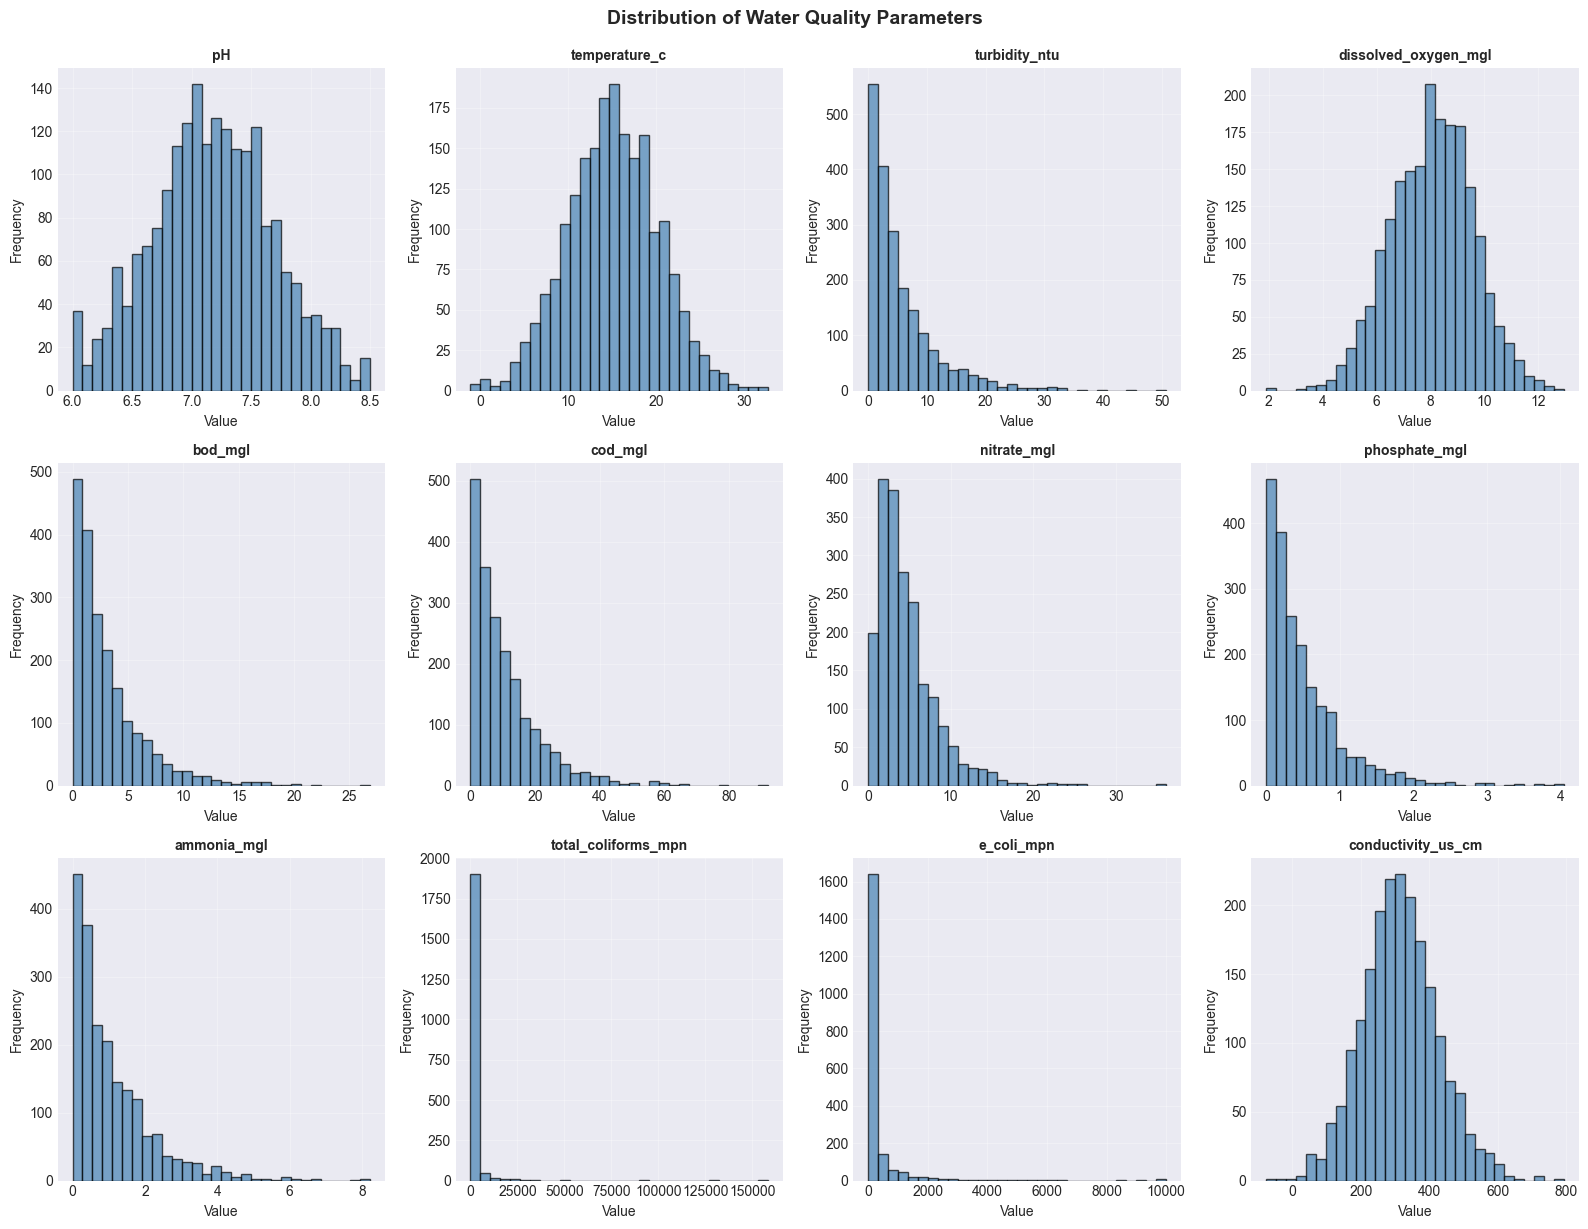

In [15]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

numeric_cols = ['pH', 'temperature_c', 'turbidity_ntu', 'dissolved_oxygen_mgl', 
                'bod_mgl', 'cod_mgl', 'nitrate_mgl', 'phosphate_mgl', 
                'ammonia_mgl', 'total_coliforms_mpn', 'e_coli_mpn', 'conductivity_us_cm']

for i, col in enumerate(numeric_cols):
    axes[i].hist(water_quality_df[col], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Distribution of Water Quality Parameters', fontsize=14, fontweight='bold', y=1.02)
plt.show()

# Correlation Heatmap to show strong concentration 

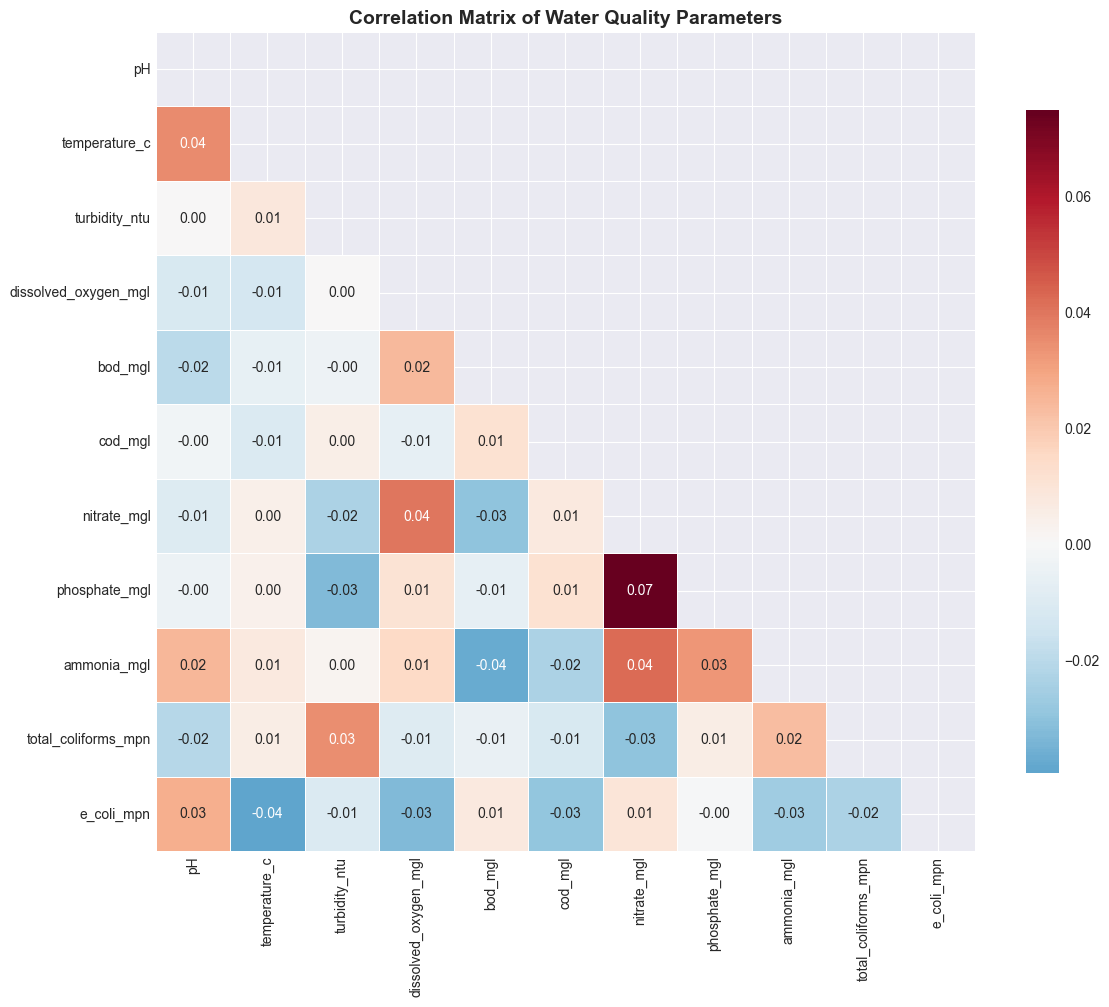


Strongest Positive Correlations:
  nitrate_mgl - phosphate_mgl: 0.075
  phosphate_mgl - nitrate_mgl: 0.075
  nitrate_mgl - ammonia_mgl: 0.043
  ammonia_mgl - nitrate_mgl: 0.043
  dissolved_oxygen_mgl - nitrate_mgl: 0.040

Strongest Negative Correlations:
  e_coli_mpn - dissolved_oxygen_mgl: -0.033
  ammonia_mgl - bod_mgl: -0.037
  bod_mgl - ammonia_mgl: -0.037
  temperature_c - e_coli_mpn: -0.040
  e_coli_mpn - temperature_c: -0.040


In [16]:
plt.figure(figsize=(12, 10))

corr_cols = ['pH', 'temperature_c', 'turbidity_ntu', 'dissolved_oxygen_mgl', 
             'bod_mgl', 'cod_mgl', 'nitrate_mgl', 'phosphate_mgl', 
             'ammonia_mgl', 'total_coliforms_mpn', 'e_coli_mpn']

corr_matrix = water_quality_df[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title('Correlation Matrix of Water Quality Parameters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print strongest correlations
print("\nStrongest Positive Correlations:")
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
for pair, corr in corr_pairs[corr_pairs < 1].head(5).items():
    print(f"  {pair[0]} - {pair[1]}: {corr:.3f}")

print("\nStrongest Negative Correlations:")
for pair, corr in corr_pairs[corr_pairs < 0].tail(5).items():
    print(f"  {pair[0]} - {pair[1]}: {corr:.3f}")

# Generate AMR Data 


In [17]:
amr_df = generator.generate_amr_data(water_quality_df)

print("\nAMR Data Sample:")
display(amr_df.head(10))

print("\nAMR Data Summary:")
print(f"Total tests: {len(amr_df):,}")
print(f"Resistance rate: {amr_df['resistant'].mean()*100:.1f}%")
print(f"Number of bacteria types: {amr_df['bacteria'].nunique()}")
print(f"Number of antibiotics: {amr_df['antibiotic'].nunique()}")
print(f"Number of locations: {amr_df['location'].nunique()}")

# Resistance by bacteria
print("\nResistance Rate by Bacteria:")
res_by_bacteria = amr_df.groupby('bacteria')['resistant'].mean().sort_values(ascending=False)
for bacteria, rate in res_by_bacteria.items():
    print(f"  {bacteria}: {rate*100:.1f}%")

Generating AMR data...
✓ Generated 90000 AMR test results

AMR Data Sample:


,sample_id,date,location,bacteria,antibiotic,resistant,mic_value,interpretation
0,0,2022-04-02 09:23:19.299649,River_B (Agricultural),Escherichia coli,Ampicillin,False,3.794453,S
1,0,2022-04-02 09:23:19.299649,River_B (Agricultural),Escherichia coli,Ciprofloxacin,False,0.275362,S
2,0,2022-04-02 09:23:19.299649,River_B (Agricultural),Escherichia coli,Gentamicin,False,2.617497,S
3,0,2022-04-02 09:23:19.299649,River_B (Agricultural),Escherichia coli,Tetracycline,True,254.118221,R
4,0,2022-04-02 09:23:19.299649,River_B (Agricultural),Escherichia coli,Ceftriaxone,True,61.719691,R
5,0,2022-04-02 09:23:19.299649,River_B (Agricultural),Escherichia coli,Meropenem,False,1.377196,S
6,0,2022-04-02 09:23:19.299649,River_B (Agricultural),Escherichia coli,Vancomycin,False,1.830297,S
7,0,2022-04-02 09:23:19.299649,River_B (Agricultural),Escherichia coli,Azithromycin,True,163.213808,R
8,0,2022-04-02 09:23:19.299649,River_B (Agricultural),Escherichia coli,Colistin,True,195.669771,R
9,0,2022-04-02 09:23:19.299649,River_B (Agricultural),Klebsiella pneumoniae,Ampicillin,True,125.558407,R



AMR Data Summary:
Total tests: 90,000
Resistance rate: 40.0%
Number of bacteria types: 5
Number of antibiotics: 9
Number of locations: 5

Resistance Rate by Bacteria:
  Acinetobacter baumannii: 49.8%
  Pseudomonas aeruginosa: 46.2%
  Klebsiella pneumoniae: 39.5%
  Escherichia coli: 33.6%
  Enterococcus faecalis: 30.8%


# Heatmap Concentration of the Antimicrobial resistance test 

ANTIMICROBIAL RESISTANCE DATA SUMMARY

 Overall Statistics:
  Total tests: 90,000
  Overall resistance rate: 40.0%
  Number of bacteria species: 5
  Number of antibiotics: 9
  Number of locations: 5

 Resistance by Bacteria:
  Acinetobacter baumannii       :  49.8%
  Pseudomonas aeruginosa        :  46.2%
  Klebsiella pneumoniae         :  39.5%
  Escherichia coli              :  33.6%
  Enterococcus faecalis         :  30.8%

 Resistance by Antibiotic:
  Ampicillin          :  63.0%
  Tetracycline        :  58.4%
  Azithromycin        :  49.6%
  Ciprofloxacin       :  45.7%
  Gentamicin          :  42.0%
  Ceftriaxone         :  37.9%
  Vancomycin          :  25.1%
  Meropenem           :  20.7%
  Colistin            :  17.4%

 Resistance by Location:
  River_A (Urban)                    :  42.0%
  River_B (Agricultural)             :  41.9%
  Lake_C (Recreational)              :  39.2%
  Reservoir_E (Drinking Water)       :  38.5%
  Well_D (Groundwater)               :  38.4%


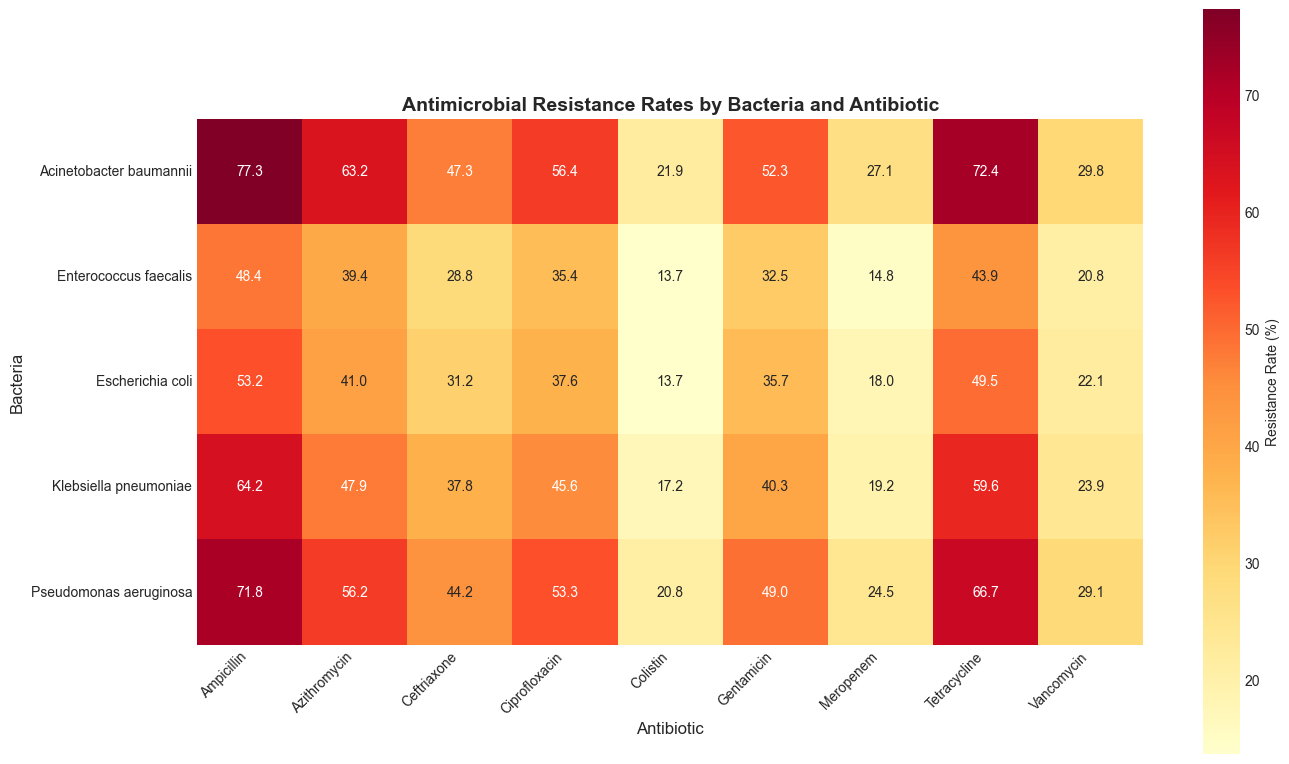

In [18]:
# resistance matrix
resistance_matrix = amr_df.pivot_table(
    values='resistant',
    index='bacteria',
    columns='antibiotic',
    aggfunc='mean'
) * 100

# summary statistics
print("=" * 80)
print("ANTIMICROBIAL RESISTANCE DATA SUMMARY")
print("=" * 80)

print(f"\n Overall Statistics:")
print(f"  Total tests: {len(amr_df):,}")
print(f"  Overall resistance rate: {amr_df['resistant'].mean()*100:.1f}%")
print(f"  Number of bacteria species: {amr_df['bacteria'].nunique()}")
print(f"  Number of antibiotics: {amr_df['antibiotic'].nunique()}")
print(f"  Number of locations: {amr_df['location'].nunique()}")

print(f"\n Resistance by Bacteria:")
res_by_bacteria = amr_df.groupby('bacteria')['resistant'].mean() * 100
for bact, rate in res_by_bacteria.sort_values(ascending=False).items():
    print(f"  {bact:30s}: {rate:5.1f}%")

print(f"\n Resistance by Antibiotic:")
res_by_abx = amr_df.groupby('antibiotic')['resistant'].mean() * 100
for abx, rate in res_by_abx.sort_values(ascending=False).items():
    print(f"  {abx:20s}: {rate:5.1f}%")

print(f"\n Resistance by Location:")
res_by_loc = amr_df.groupby('location')['resistant'].mean() * 100
for loc, rate in res_by_loc.sort_values(ascending=False).items():
    print(f"  {loc:35s}: {rate:5.1f}%")

# Create heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(resistance_matrix, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': 'Resistance Rate (%)'}, square=True)

plt.title('Antimicrobial Resistance Rates by Bacteria and Antibiotic', 
          fontsize=14, fontweight='bold')
plt.xlabel('Antibiotic', fontsize=12)
plt.ylabel('Bacteria', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Correlation with AMR

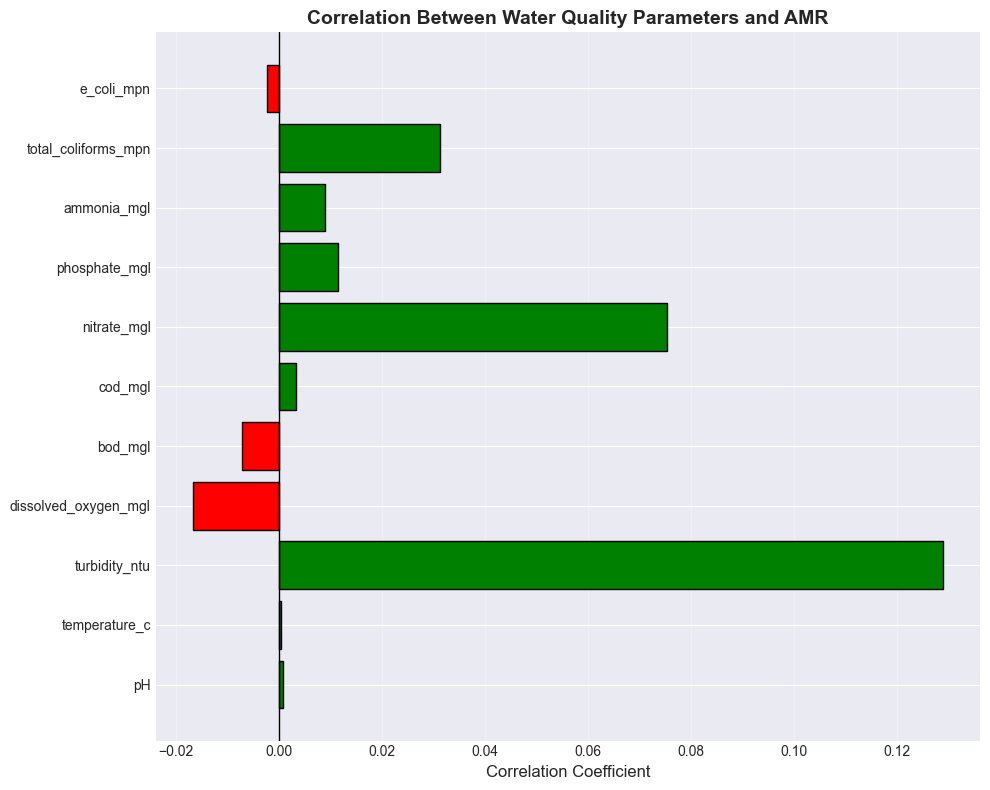


Top 5 Parameters Correlated with AMR:
  turbidity_ntu: 0.129 (positive)
  nitrate_mgl: 0.075 (positive)
  total_coliforms_mpn: 0.031 (positive)
  dissolved_oxygen_mgl: -0.017 (negative)
  phosphate_mgl: 0.011 (positive)


In [19]:
merged_df = pd.merge(
    amr_df,
    water_quality_df,
    on=['sample_id', 'date', 'location'],
    how='left'
)

water_params = ['pH', 'temperature_c', 'turbidity_ntu', 'dissolved_oxygen_mgl', 
                'bod_mgl', 'cod_mgl', 'nitrate_mgl', 'phosphate_mgl', 
                'ammonia_mgl', 'total_coliforms_mpn', 'e_coli_mpn']

correlations = {}
for param in water_params:
    corr = merged_df[param].corr(merged_df['resistant'].astype(float))
    correlations[param] = corr

plt.figure(figsize=(10, 8))
colors = ['red' if x < 0 else 'green' for x in correlations.values()]
plt.barh(list(correlations.keys()), list(correlations.values()), color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.title('Correlation Between Water Quality Parameters and AMR', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 5 Parameters Correlated with AMR:")
sorted_corr = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)
for param, corr in sorted_corr[:5]:
    direction = "positive" if corr > 0 else "negative"
    print(f"  {param}: {corr:.3f} ({direction})")

# Temporal Analysis

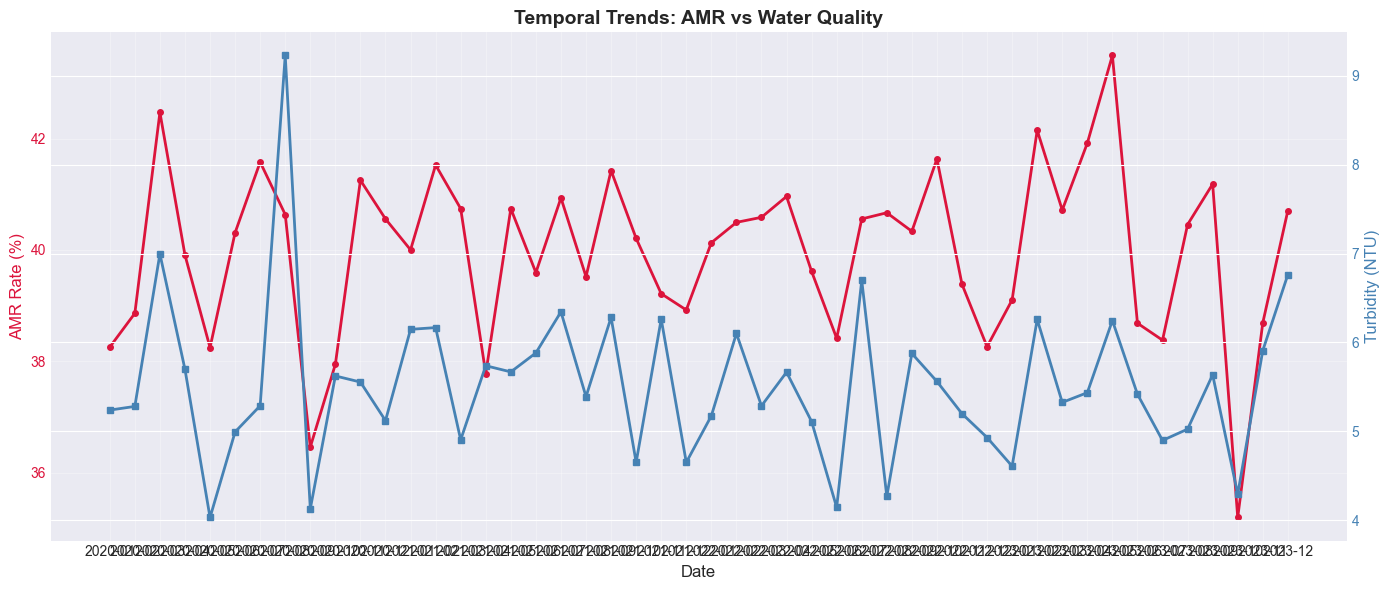

In [22]:
merged_df['year_month'] = merged_df['date'].dt.to_period('M')
monthly_resistance = merged_df.groupby('year_month')['resistant'].mean() * 100
monthly_turbidity = merged_df.groupby('year_month')['turbidity_ntu'].mean()

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(monthly_resistance.index.astype(str), monthly_resistance.values, 
         color='crimson', marker='o', linewidth=2, markersize=4, label='AMR Rate')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('AMR Rate (%)', fontsize=12, color='crimson')
ax1.tick_params(axis='y', labelcolor='crimson')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(monthly_turbidity.index.astype(str), monthly_turbidity.values, 
         color='steelblue', marker='s', linewidth=2, markersize=4, label='Turbidity')
ax2.set_ylabel('Turbidity (NTU)', fontsize=12, color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

plt.title('Temporal Trends: AMR vs Water Quality', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

# Save the generated dataset

In [23]:
import os

# Create directories
os.makedirs('../data/raw/water_quality', exist_ok=True)
os.makedirs('../data/raw/amr', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

# Save data
water_quality_df.to_csv('../data/raw/water_quality/water_quality_raw.csv', index=False)
amr_df.to_csv('../data/raw/amr/amr_raw.csv', index=False)
merged_df.to_csv('../data/processed/merged_data.csv', index=False)

print("✓ Data saved successfully!")
print(f"  - Water quality data: {len(water_quality_df):,} records")
print(f"  - AMR data: {len(amr_df):,} records")
print(f"  - Merged data: {len(merged_df):,} records")

# Save summary statistics
summary = {
    'total_samples': len(water_quality_df),
    'total_amr_tests': len(amr_df),
    'overall_resistance_rate': float(amr_df['resistant'].mean()),
    'num_locations': water_quality_df['location'].nunique(),
    'num_bacteria': amr_df['bacteria'].nunique(),
    'num_antibiotics': amr_df['antibiotic'].nunique(),
    'date_range': f"{water_quality_df['date'].min()} to {water_quality_df['date'].max()}"
}

import json
with open('../data/processed/data_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print("\nData Summary:")
for key, value in summary.items():
    print(f"  {key}: {value}")

✓ Data saved successfully!
  - Water quality data: 2,000 records
  - AMR data: 90,000 records
  - Merged data: 90,000 records

Data Summary:
  total_samples: 2000
  total_amr_tests: 90000
  overall_resistance_rate: 0.39976666666666666
  num_locations: 5
  num_bacteria: 5
  num_antibiotics: 9
  date_range: 2020-01-01 00:00:00 to 2023-12-30 06:28:16.448224
